In [1]:
import RealCodedGeneticAlgorithm as rcga
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
#pip show numpy

In [3]:
#pip install numpy==1.19.3 --user

In [4]:
#%run verification.py

In [5]:
#test_LinearLeastSquares_withRCGA()

In [6]:
#test_Minimize_L2_1()

In [7]:
def minus_l2(genes):
    #"""
    evals = ((genes[:,:-1]**2+genes[:,1:]**2)**0.25 \
                 *(np.sin(50*(genes[:,:-1]**2+genes[:,1:]**2)**0.1)**2 \
                +1.0)).sum(axis=1) #schaffer
    #"""
    """
    evals = (genes**2).sum(axis=-1) #sphere
    """
    """
    num_rows = genes.shape[0]
    multiplier = 1 / np.arange(1, num_rows + 1).reshape(-1, 1)
    multiplied_genes = (genes**2) * multiplier

    evals = multiplied_genes.sum(axis=-1) #scaled shere
    """
    """
    num_rows = genes.shape[0]
    multiplier = 1 / np.arange(1, num_rows + 1).reshape(-1, 1)
    def helmert_matrix(n):
        H = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == 0:
                    H[i, j] = 1 / np.sqrt(n)
                elif i >= 1 and j >= i:
                    H[i, j] = -1 / np.sqrt(i * (i + 1))
        return H.T
    multiplied_genes = np.dot(helmert_matrix(num_rows),multiplier)*(genes**2)
    evals = multiplied_genes.sum(axis=-1) #scaled rotated shere
    return evals
    """
    
    """
    input_array_1st = genes[:,:1]
    input_array_rest = genes[:,1:]
    evals = ((input_array_1st**2)+((1000*input_array_rest)**2)).sum(axis=1) #cigar
    """
    """
    dim = genes.shape[1]     
    k = math.ceil(dim/4)
                
    evals = (genes[:,:k]**2).sum(axis=1) \
            +((100*genes[:,k:])**2).sum(axis=1) #k-tablet
    """
    """
    input_array_1st = genes[:,:1]
    input_array_rest = genes[:,1:]
        
    evals = (100*(input_array_1st-input_array_rest**2)**2 \
            +(1-input_array_rest)**2).sum(axis=1) #rosenbrock_star
    """
    """
    input_array = genes
    evals = (100*(input_array[:,1:]-input_array[:,:-1]**2)**2 \
                +(1-input_array[:,:-1])**2).sum(axis=1) #rosenbrock_chain
    """
    """
    input_array = genes
    evals = (input_array[:,:-1]**2 \
                +2*input_array[:,1:]**2 \
                -0.3*np.cos(3*np.pi*input_array[:,:-1]) \
                -0.4*np.cos(4*np.pi*input_array[:,1:]) \
                +0.7).sum(axis=1) #bohachevsky
    """
    """
    input_array = genes
    dim = input_array.shape[1]
    evals = 10*dim + \
                ((input_array-1)**2-10*np.cos(2*np.pi*(input_array-1))).sum(axis=1) #rastrigin
    """
    return evals
gene_num = 40

arex = rcga.RealCodecGA_JGG_AREX(gene_num=gene_num, evaluation_func=minus_l2, initial_min=-100, initial_max=100, population=(gene_num*20),
                                                     crossover_num=gene_num + 1,child_num=gene_num*4,initial_expantion_rate=1.0, learning_rate=0.05,seed=4)
#gene_num*1000
cs = []
cm = []
"""
for i in range(5):
    arex.generation_step(i)
    print('{0}'.format(i+1))
    print(' best evals : {0:.10f}'.format(arex.best_evaluation))
    print(' runtime : {0:.10f}'.format(arex.runtime))
    #print(arex.survive)
    #print(arex.histime)
    #print(arex.wG)
    print(arex.genes)
    #print(arex.zone0)
    #print(arex.zone1)
    #print(arex.count_greatercs)
    #print(arex.count_greatercm)
    #print(arex.mae)
    #print(arex.ato)
    #print(arex._cs)
    #print(arex.var)
    #print(arex.senyu)
    #print(arex.deka)
    #print(arex.dekamae)
    #print(arex.uwo)
    cs.append(arex.count_greatercs)
    cm.append(arex.count_greatercm)
    if arex.best_evaluation < 0.0000001:
        break
        #print(' best genes : {0:.10f}'.format(arex.best_gene))
"""

"\nfor i in range(5):\n    arex.generation_step(i)\n    print('{0}'.format(i+1))\n    print(' best evals : {0:.10f}'.format(arex.best_evaluation))\n    print(' runtime : {0:.10f}'.format(arex.runtime))\n    #print(arex.survive)\n    #print(arex.histime)\n    #print(arex.wG)\n    print(arex.genes)\n    #print(arex.zone0)\n    #print(arex.zone1)\n    #print(arex.count_greatercs)\n    #print(arex.count_greatercm)\n    #print(arex.mae)\n    #print(arex.ato)\n    #print(arex._cs)\n    #print(arex.var)\n    #print(arex.senyu)\n    #print(arex.deka)\n    #print(arex.dekamae)\n    #print(arex.uwo)\n    cs.append(arex.count_greatercs)\n    cm.append(arex.count_greatercm)\n    if arex.best_evaluation < 0.0000001:\n        break\n        #print(' best genes : {0:.10f}'.format(arex.best_gene))\n"

In [8]:
# 試行回数
TRIALS = 10
MAX_GENERATIONS = gene_num * 200

# 結果を保存するリスト
results_generation = []
results_runtime = []

print(f"--- {TRIALS}回の試行を開始します ---")

for trial in range(TRIALS):
    # 【重要】試行ごとにGAのインスタンスを生成し直します
    # seed=trial とすることで、毎回異なる乱数パターンで実行されます
    arex = rcga.RealCodecGA_JGG_AREX(
        gene_num=gene_num, 
        evaluation_func=minus_l2, 
        initial_min=-100, 
        initial_max=100, 
        population=(gene_num*5),
        crossover_num=gene_num + 1,
        child_num=gene_num*4,
        initial_expantion_rate=1.0, 
        learning_rate=0.05,
        seed=trial+1  # ここを固定値にすると毎回同じ結果になります
    )
    
    # 1回の試行におけるループ
    converged = False
    for i in range(MAX_GENERATIONS):
        arex.generation_step(i)
        
        # 収束判定
        if arex.best_evaluation < 0.0000001:
            # 収束した場合
            generations = i + 1
            runtime = arex.runtime
            
            results_generation.append(generations)
            results_runtime.append(runtime)
            
            print(f"Trial {trial+1:02d}: Conv at Gen {generations}, Time {runtime:.4f}s")
            converged = True
            break
    
    # 指定世代数まで収束しなかった場合の処理（必要に応じて変更してください）
    if not converged:
        print(f"Trial {trial+1:02d}: Not Converged (Max Gen reached)")
        # 収束しなかったデータを平均に含めるかは運用によりますが、ここでは最大値を入れておきます
        results_generation.append(MAX_GENERATIONS)
        results_runtime.append(arex.runtime)

print("-" * 30)

# --- 統計量の計算と表示 ---
if len(results_generation) > 0:
    # 世代数の統計
    gen_mean = np.mean(results_generation)
    gen_std = np.std(results_generation)

    # CPU時間の統計
    time_mean = np.mean(results_runtime)
    time_std = np.std(results_runtime)

    print(f"【結果まとめ ({len(results_generation)}/{TRIALS} trials)】")
    print(f"Generation - Mean: {gen_mean:.2f}, Std: {gen_std:.2f}")
    print(f"CPU Time   - Mean: {time_mean:.4f}s, Std: {time_std:.4f}s")
else:
    print("有効なデータがありませんでした。")

--- 10回の試行を開始します ---
Trial 01: Conv at Gen 856, Time 1.9069s
Trial 02: Conv at Gen 784, Time 1.7310s
Trial 03: Conv at Gen 868, Time 1.8899s
Trial 04: Conv at Gen 867, Time 2.0550s
Trial 05: Conv at Gen 686, Time 1.5300s
Trial 06: Conv at Gen 794, Time 1.7298s
Trial 07: Conv at Gen 774, Time 1.7303s
Trial 08: Conv at Gen 860, Time 1.8887s
Trial 09: Conv at Gen 830, Time 1.9258s
Trial 10: Conv at Gen 820, Time 1.9299s
------------------------------
【結果まとめ (10/10 trials)】
Generation - Mean: 813.90, Std: 54.02
CPU Time   - Mean: 1.8317s, Std: 0.1423s


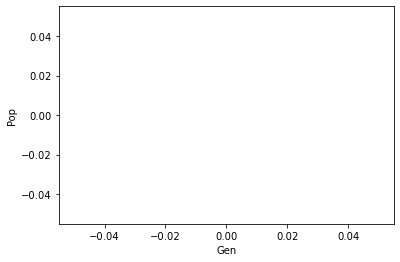

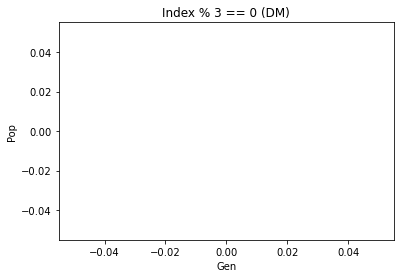

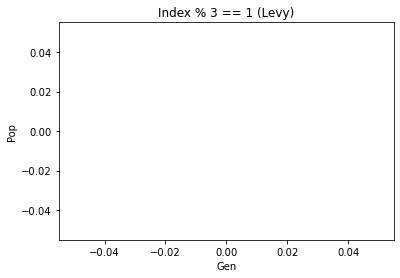

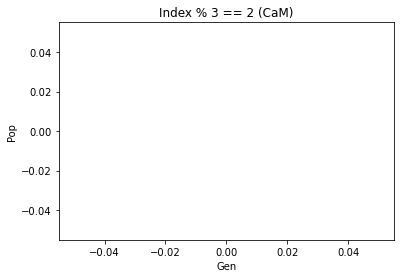

In [9]:
import matplotlib.pyplot as plt


# インデックスを生成
a = cm
x = range(len(a))

# 各棒の色を条件で決定
colors = []
for i in x:
    if i % 3 == 1:
        colors.append('blue')
    elif i % 3 == 2:
        colors.append('red')
    else:
        colors.append('green')

# 棒グラフを描画
plt.bar(x, a, color=colors)

# 軸ラベル・タイトル
plt.xlabel("Gen")
plt.ylabel("Pop")
#plt.title("Bar Graph with Colors Based on Index % 3")

# グラフの表示
plt.show()


x = range(len(a))

# 各グループごとにデータを抽出
a_mod0 = [a[i] for i in x if i % 3 == 0]
a_mod1 = [a[i] for i in x if i % 3 == 1]
a_mod2 = [a[i] for i in x if i % 3 == 2]

x_mod0 = [i for i in x if i % 3 == 0]
x_mod1 = [i for i in x if i % 3 == 1]
x_mod2 = [i for i in x if i % 3 == 2]

# 緑のグラフ（余り0）
plt.xlabel("Gen")
plt.ylabel("Pop")
plt.bar(x_mod0, a_mod0, color='green')
plt.title("Index % 3 == 0 (DM)")
plt.show()

# 青のグラフ（余り1）
plt.xlabel("Gen")
plt.ylabel("Pop")
plt.bar(x_mod1, a_mod1, color='blue')
plt.title("Index % 3 == 1 (Levy)")
plt.show()

# 赤のグラフ（余り2）
plt.xlabel("Gen")
plt.ylabel("Pop")
plt.bar(x_mod2, a_mod2, color='red')
plt.title("Index % 3 == 2 (CaM)")
plt.show()

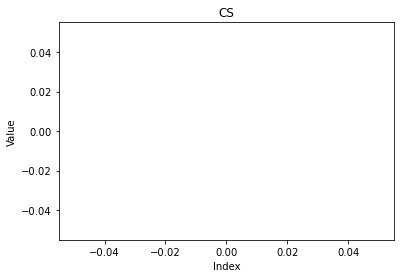

In [10]:
## 配列 b の例
b = cs

# x軸にインデックスを設定
x = range(len(b))

# 棒グラフを描画
plt.bar(x, b, color='skyblue')

# 軸ラベルやタイトルを設定
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("CS")

# グラフを表示
plt.show()